# Dataset Description:
#### The dataset contains 32 columns and a total of 569 rows. Each row corresponds to a unique patient with a breast cancer diagnosis. The features are derived from digitized images of a breast mass and describe various characteristics of the tumor, such as its size, shape, and texture. These features are statistical values such as the mean, standard error, and worst values for several tumor properties. The dataset's columns include:

#### id: A unique identifier for each sample.
#### diagnosis: A categorical label indicating whether the tumor is malignant (M) or benign (B).
#### radius_mean, texture_mean, perimeter_mean, area_mean, ... : The mean values of different tumor properties (radius, texture, perimeter, area, smoothness, etc.).
#### radius_worst, texture_worst, perimeter_worst, area_worst, ... : The worst values of the tumor properties, representing the most extreme measurements from the image.
#### radius_se, texture_se, perimeter_se, area_se, ... : The standard error of the tumor properties. The goal of the analysis is to predict the diagnosis of each tumor (whether it is malignant or benign) based on these features.

# Model Description:
#### For this classification task, a machine learning model is trained to predict whether a given tumor is malignant (M) or benign (B). Common models for this type of problem include:

#### Logistic Regression: A statistical model that predicts a binary outcome (malignant or benign) by learning the relationship between the features and the diagnosis. It uses the logistic function to output a probability that a given tumor is malignant.
#### Decision Tree: A tree-like model that splits the data based on the feature values to make a decision at each node. It can model non-linear relationships and is interpretable.
#### Random Forest: An ensemble of decision trees that averages the predictions of many individual trees, making it more robust and less prone to overfitting compared to a single decision tree.
#### The target variable is the diagnosis column, which is converted to a binary variable, where 1 represents malignant (M) and 0 represents benign (B).

# Predictive Task:
#### The task is a binary classification problem to predict the diagnosis of breast cancer based on the tumor's characteristics. Given the features such as mean radius, texture, perimeter, and area, the model will classify each tumor as either malignant (1) or benign (0). The evaluation of the model will be based on various metrics such as accuracy, precision, recall, F1-score, and confusion matrix.

In [1]:
!pip install dtale

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.7/642.7 kB 12.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.3/229.3 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 22.4 MB/s eta 0:00:00
  Created wheel for dash-colorscales: filename=d

## The dataset can be found in the following URL
https://www.kaggle.com/datasets/erdemtaha/cancer-data

In [2]:
#import libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import dtale

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#import the dataset
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Explainable_AI/cancer_dataset.csv')

In [5]:
data.shape

(569, 32)

In [6]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
# Convert diagnosis into a binary variable (M = 1, B = 0)
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})

# Drop the 'id' column as it's not useful for prediction
data = data.drop(columns=['id'])
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
print(data.isnull().sum())

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [9]:
print(data.dtypes)

diagnosis                    int64
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst            float64
concave points_worst

In [10]:
feature_names = data.columns
print(feature_names)

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [11]:
data.describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [12]:
counts = data['diagnosis'].value_counts()
print(counts)

diagnosis
0    357
1    212
Name: count, dtype: int64


## Exploratory Data Analysis

In [13]:
correlation_matrix = data.corr()
print(correlation_matrix["diagnosis"].sort_values(ascending=False))

diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

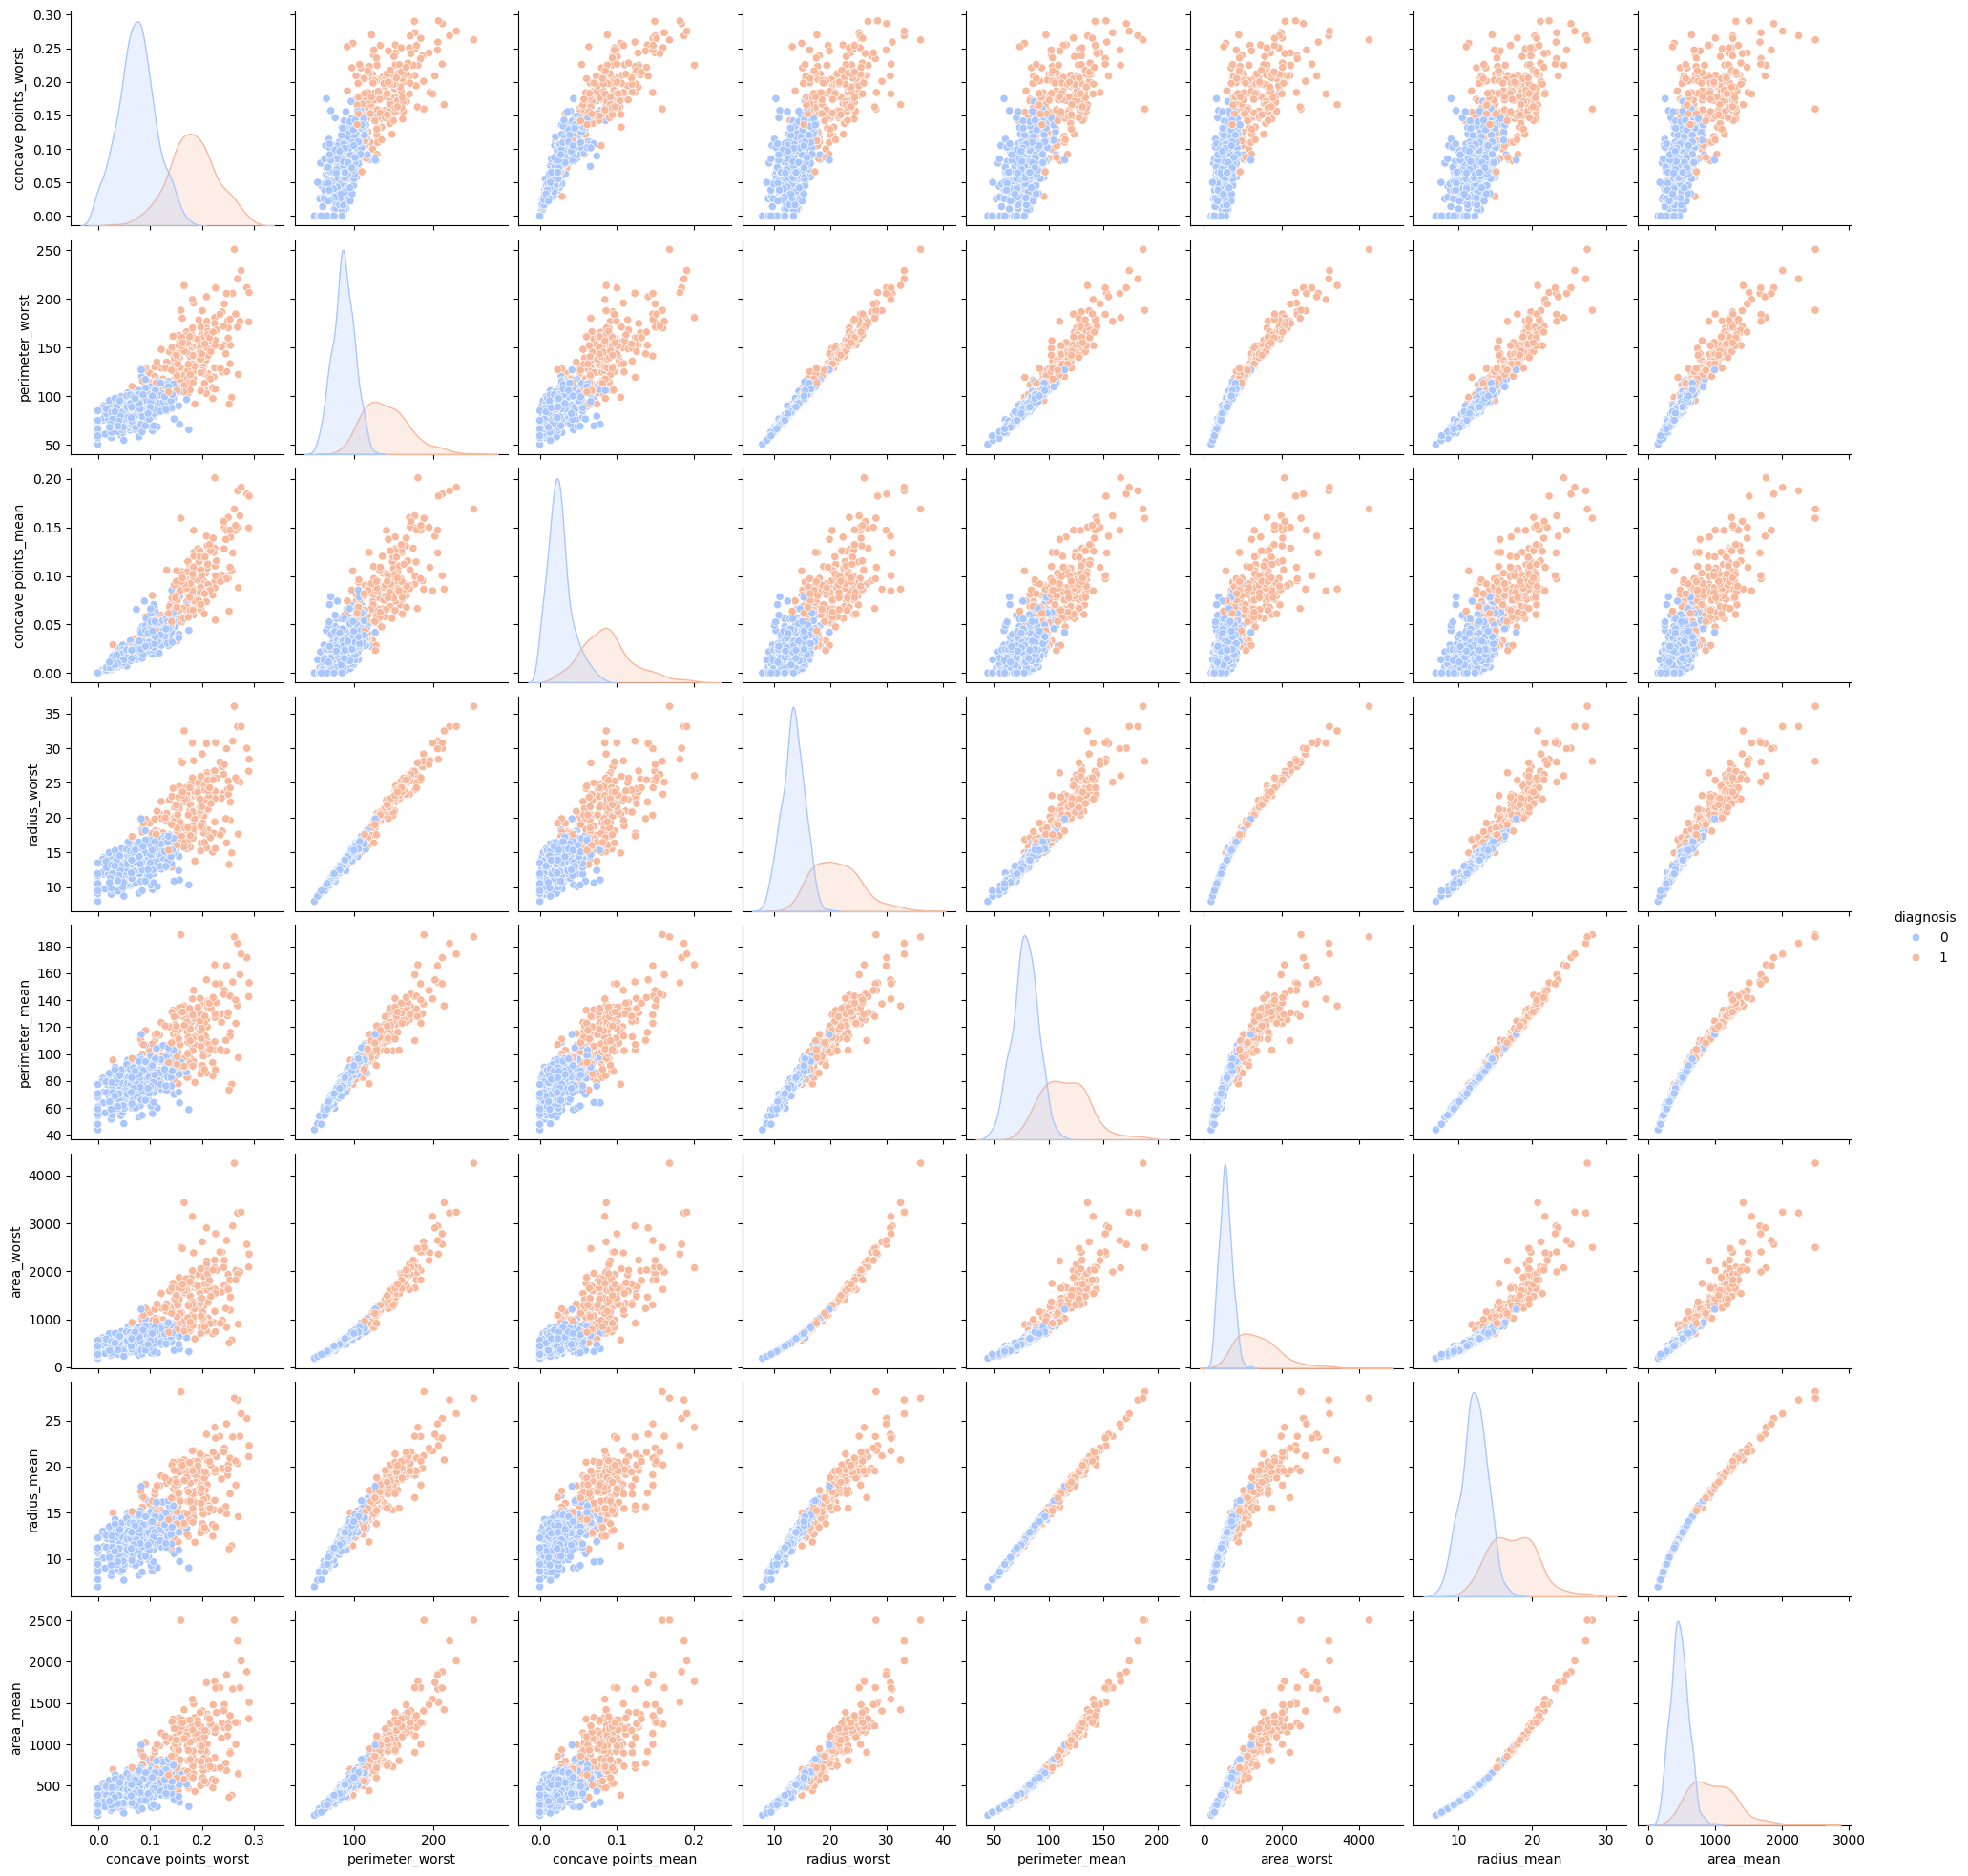

In [14]:
highly_correlated_features = [
    'concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst',
    'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean']

# Subset the data to only include these features and the 'diagnosis' column
subset_data = data[highly_correlated_features + ['diagnosis']]

# Create a pair plot
sns.pairplot(subset_data, hue='diagnosis', palette='coolwarm', diag_kind='kde')

# Display the plot
plt.show()

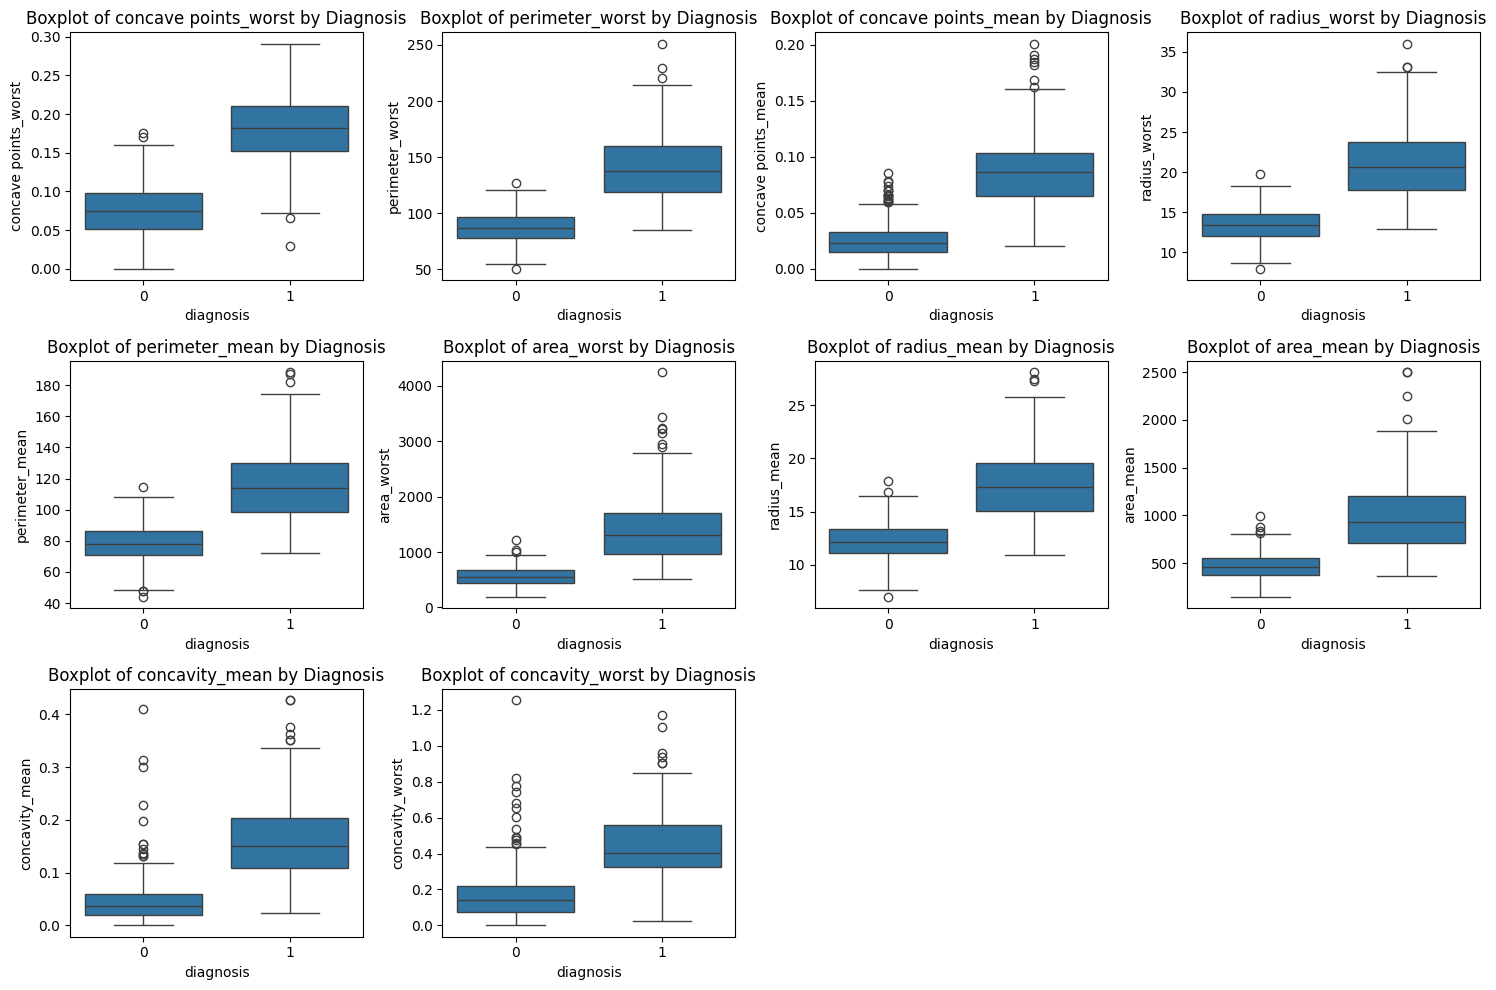

In [15]:
# List of important features based on correlation values
important_features = ['concave points_worst', 'perimeter_worst', 'concave points_mean',
                      'radius_worst', 'perimeter_mean', 'area_worst', 'radius_mean',
                      'area_mean', 'concavity_mean', 'concavity_worst']

# Create boxplots for each important feature
plt.figure(figsize=(15, 10))

for i, feature in enumerate(important_features):
    plt.subplot(3, 4, i+1)  # Adjust rows and columns if needed
    sns.boxplot(x='diagnosis', y=feature, data=data)
    plt.title(f"Boxplot of {feature} by Diagnosis")
    plt.tight_layout()

plt.show()

In [16]:
# Split the data into features (X) and target (y)
X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

# Base Model: Logistic Regression

In [17]:
# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
# Initialize the Logistic Regression model
model = LogisticRegression(max_iter=10000)

# Train the model
model.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [20]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

# Detailed performance metrics
print('Classification Report:')
print(classification_report(y_test, y_pred))

# Confusion matrix
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9737
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Confusion Matrix:
[[70  1]
 [ 2 41]]


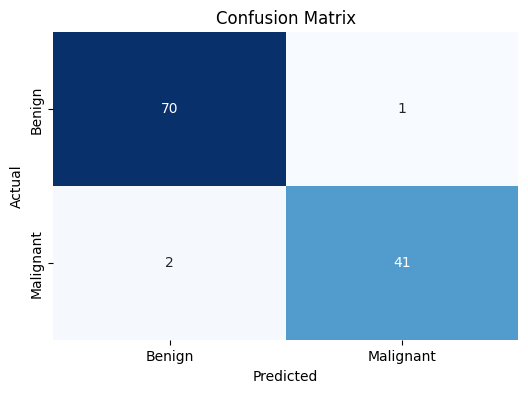

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'], cbar=False)

# Add labels and title
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show the plot
plt.show()

### Key Observations:
The results from the Logistic Regression model look quite promising:

#### Accuracy:
97.37% — This is a very high accuracy, meaning the model is correctly predicting the diagnosis for most cases.

#### Precision:
For benign (0): 97% — High precision means the model is good at correctly identifying benign cases.
For malignant (1): 98% — The model is also good at identifying malignant cases, though there's a slight trade-off compared to benign cases.

#### Recall:
For benign (0): 99% — The model is very effective at identifying benign cases without many false negatives.
For malignant (1): 95% — While still quite high, there's a slight reduction in recall for malignant cases, meaning a few malignant cases are missed (false negatives).
#### F1-score:
For benign (0): 98%
For malignant (1): 96%
These scores indicate a balanced performance between precision and recall.

#### Confusion Matrix:
True Negatives (TN): 70 — Correctly identified benign cases.
False Positives (FP): 1 — Only 1 benign case was misclassified as malignant.
False Negatives (FN): 2 — Only 2 malignant cases were misclassified as benign.
True Positives (TP): 41 — Correctly identified malignant cases.


## Determining the Falsely Predicted Indices

In [22]:
# Identify False Positives and False Negatives
false_positive_indices = np.where((y_pred == 1) & (y_test == 0))[0]
false_negative_indices = np.where((y_pred == 0) & (y_test == 1))[0]

# Show the number of false positives and false negatives
print(f"False Positives: {len(false_positive_indices)}")
print(f"False Negatives: {len(false_negative_indices)}")

# Print the indices of False Positives and False Negatives
print("False Positive Indices:", false_positive_indices)
print("False Negative Indices:", false_negative_indices)

False Positives: 1
False Negatives: 2
False Positive Indices: [112]
False Negative Indices: [20 77]


# Applying SHAP to Find the Feature Importances

In [23]:
!pip install shap

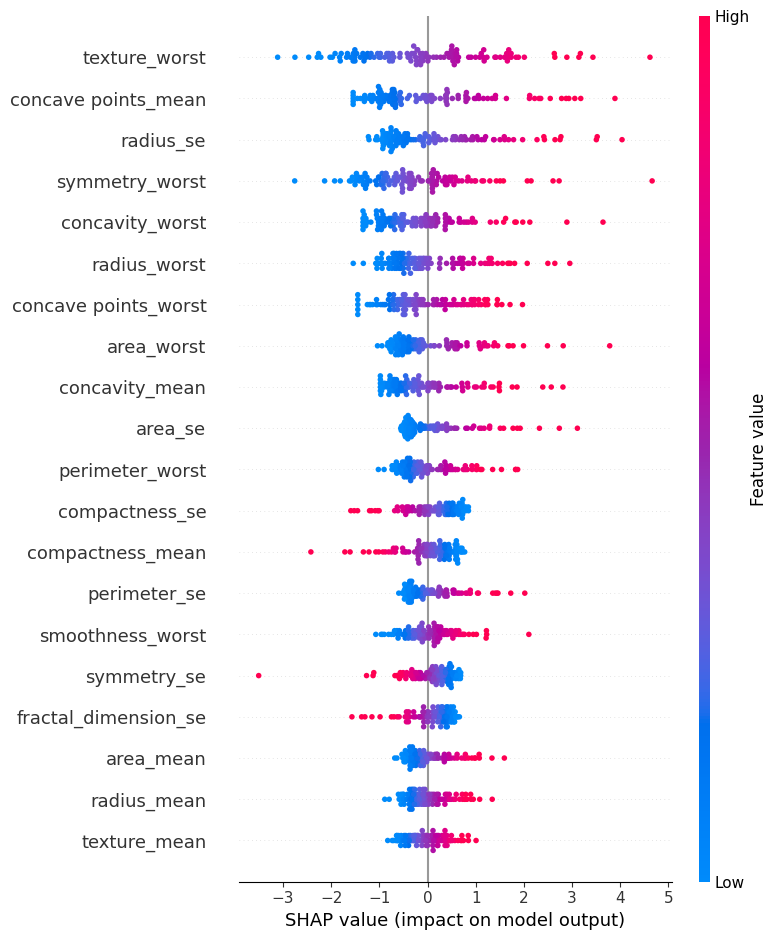

In [24]:
import shap
import matplotlib.pyplot as plt

# Ensure X_test is a DataFrame with features
X_test_df = pd.DataFrame(X_test, columns=data.drop(columns=['diagnosis']).columns)

# Initialize SHAP explainer using the trained model
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# SHAP Summary Plot with feature names
shap.summary_plot(shap_values, features=X_test_df, feature_names=X_test_df.columns)


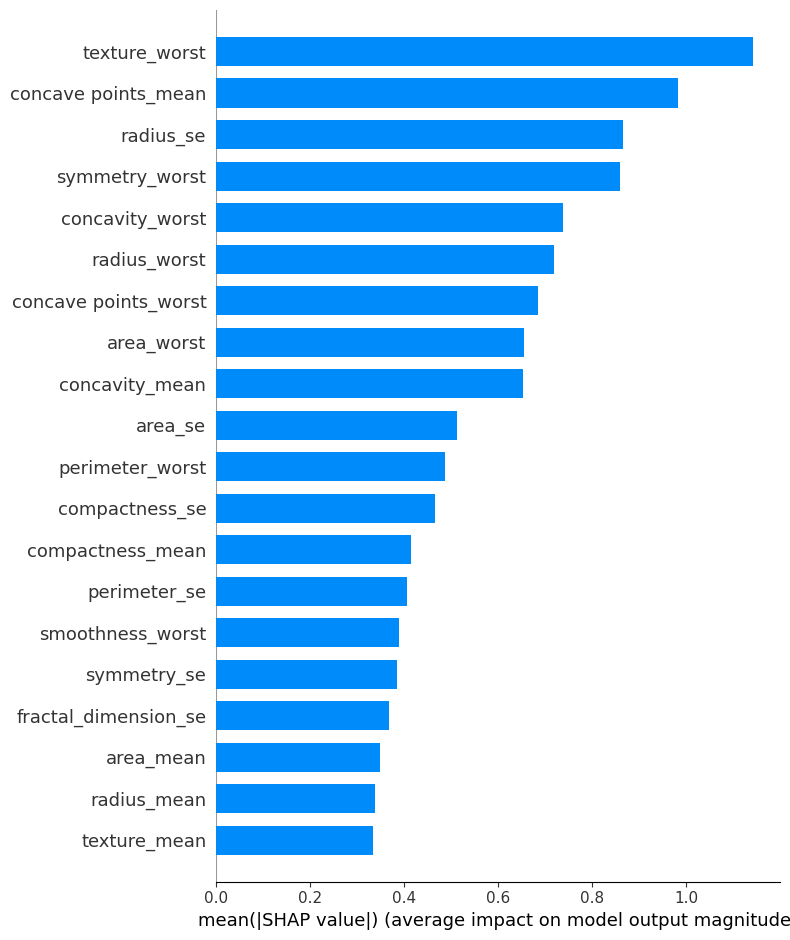

In [25]:
shap.summary_plot(shap_values, features=X_test_df, feature_names=X_test_df.columns, plot_type="bar")

# Applying SHAP to the Falsely Predicted Indices

Summary Plot for only misclassified indices:


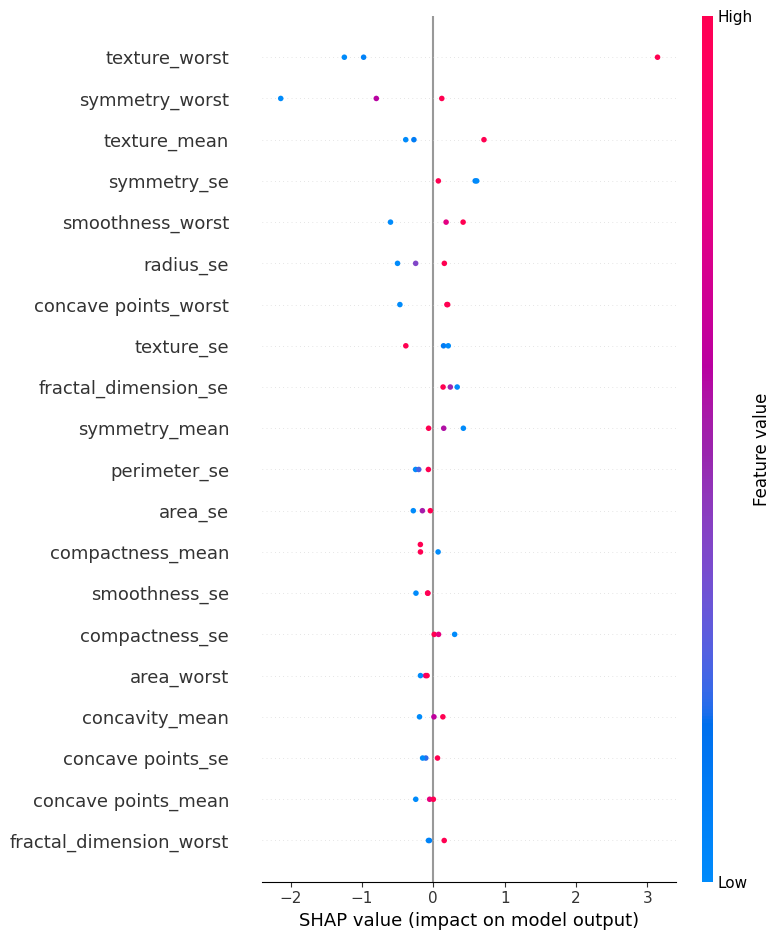

In [26]:
# Get SHAP values for the misclassified instances
X_misclassified = X_test[np.concatenate((false_positive_indices, false_negative_indices))]
shap_values = explainer(X_misclassified)

# SHAP Summary Plot
print("Summary Plot for only misclassified indices:")
shap.summary_plot(shap_values, X_misclassified, feature_names=X.columns)

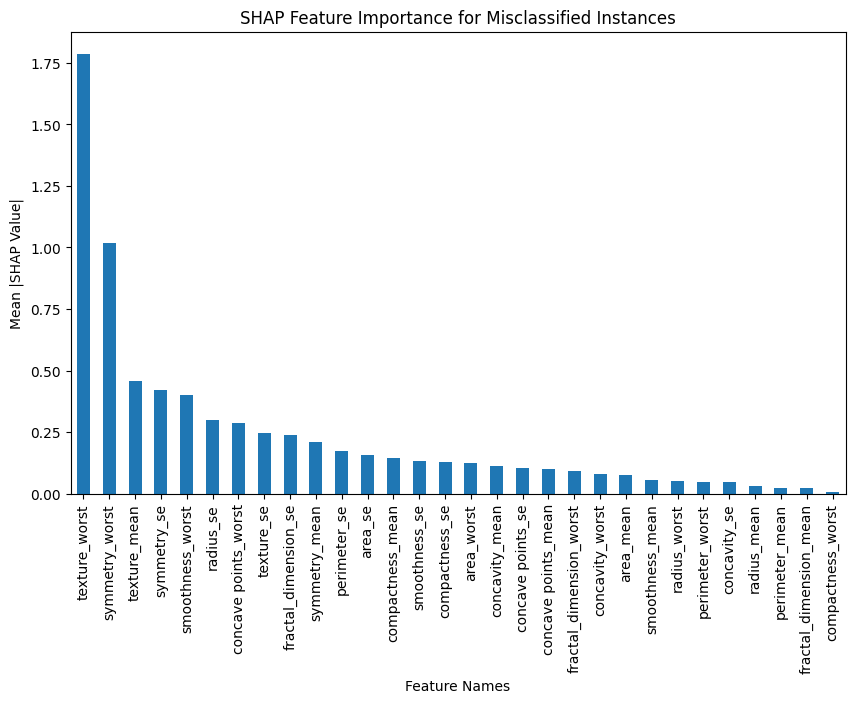

In [27]:
# Convert SHAP values to a DataFrame with feature names
shap_values_df = pd.DataFrame(shap_values.values, columns=X.columns)

# Compute mean absolute SHAP values for each feature
shap_importance = shap_values_df.abs().mean()

# Plot the feature importance as a bar plot
shap_importance.sort_values(ascending=False).plot(kind="bar", figsize=(10, 6), title="SHAP Feature Importance for Misclassified Instances")
plt.xlabel("Feature Names")
plt.ylabel("Mean |SHAP Value|")
plt.show()

## SHAP on False Positive Index: 112

In [28]:
print(X_test.shape)
print(len(feature_names))

(114, 30)
31


In [29]:
feature_names = feature_names[:X_test.shape[1]]

In [30]:
X_test_df = pd.DataFrame(X_test, columns=feature_names)

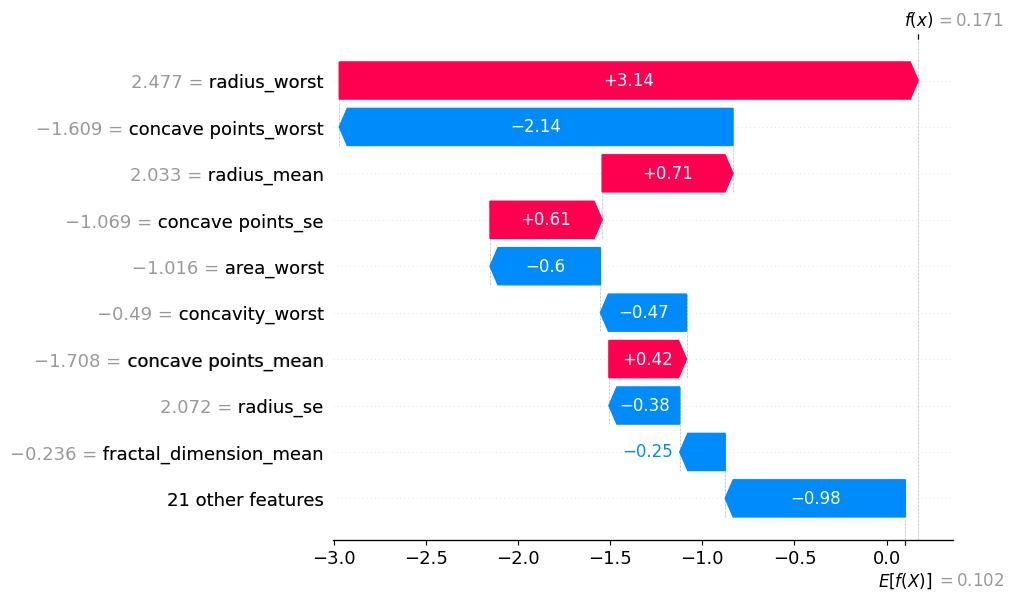

In [31]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test_df)

# Explain the false positive at index 112
shap.plots.waterfall(shap_values[112])

In [32]:
# Display the force plot for index 112
shap_index = 112

shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[shap_index].values,
    X_test_df.iloc[shap_index]
)

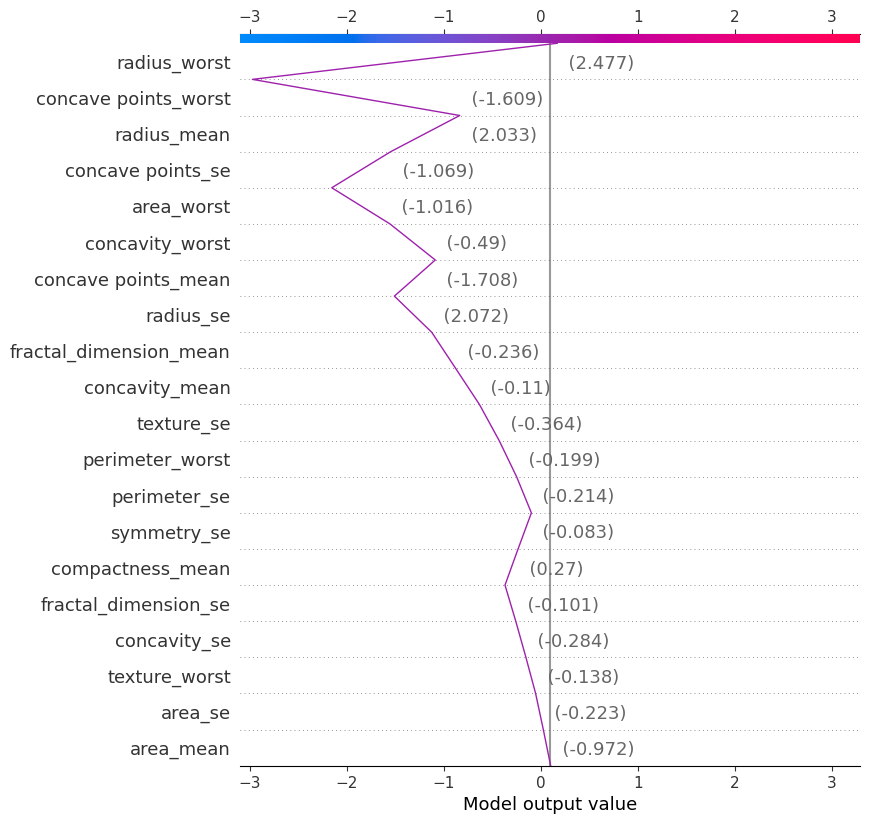

In [33]:
# Display the decision plot for index 112
shap.decision_plot(explainer.expected_value, shap_values[112].values, X_test_df.iloc[112])

## SHAP on False Negative Indices 20 & 77

Waterfall Plot for index 20:


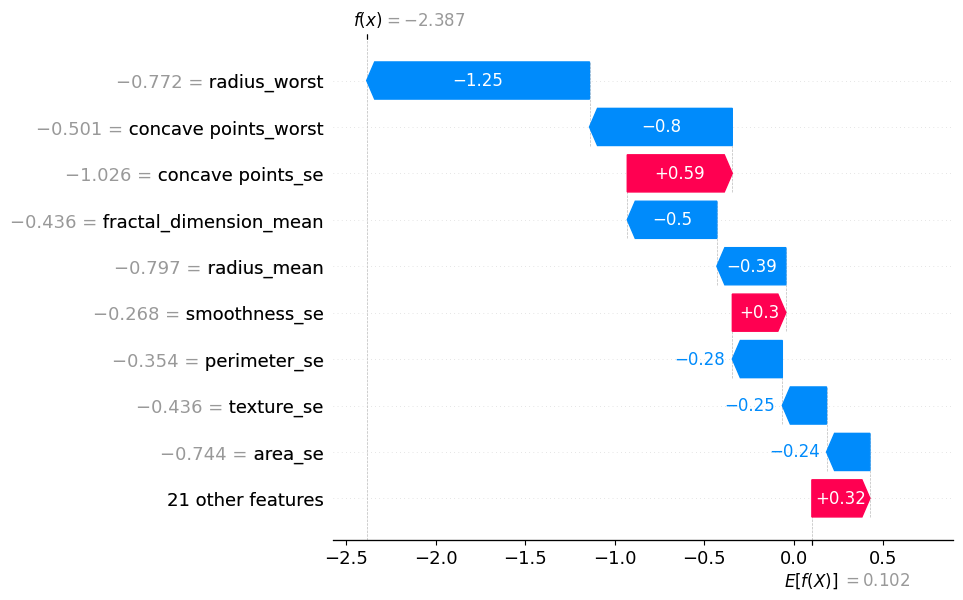

Waterfall Plot for index 77:


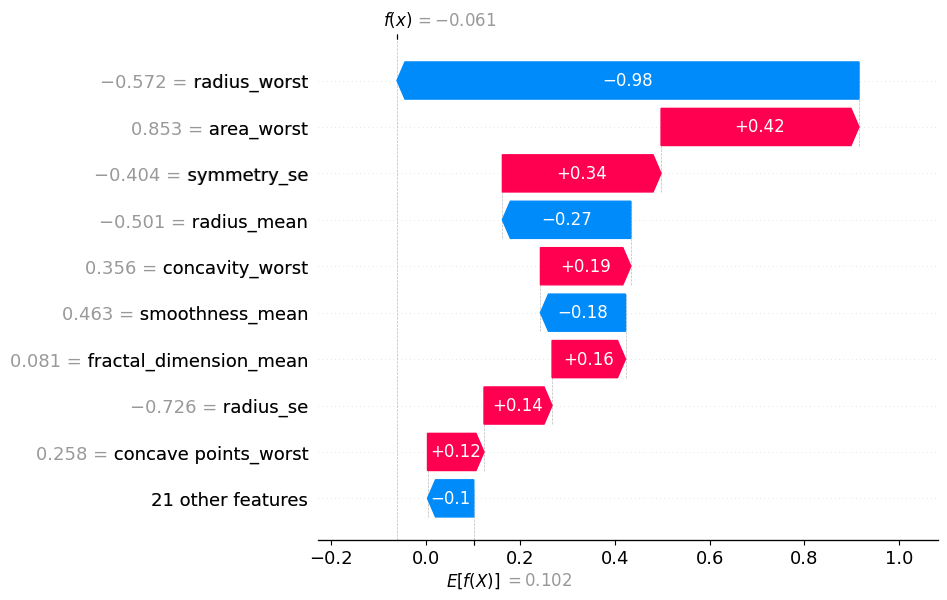

In [34]:
print("Waterfall Plot for index 20:")
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test_df)

shap.plots.waterfall(shap_values[20])

print("Waterfall Plot for index 77:")
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test_df)

shap.plots.waterfall(shap_values[77])

In [35]:
# Display the force plot for index 20
print(" Force Plot for index 20:")
shap_index = 20

shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[shap_index].values,
    X_test_df.iloc[shap_index]
)

 Force Plot for index 20:


In [36]:
# Display the force plot for index 77
print(" Force Plot for index 77:")
shap_index = 77

shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[shap_index].values,
    X_test_df.iloc[shap_index]
)

 Force Plot for index 77:


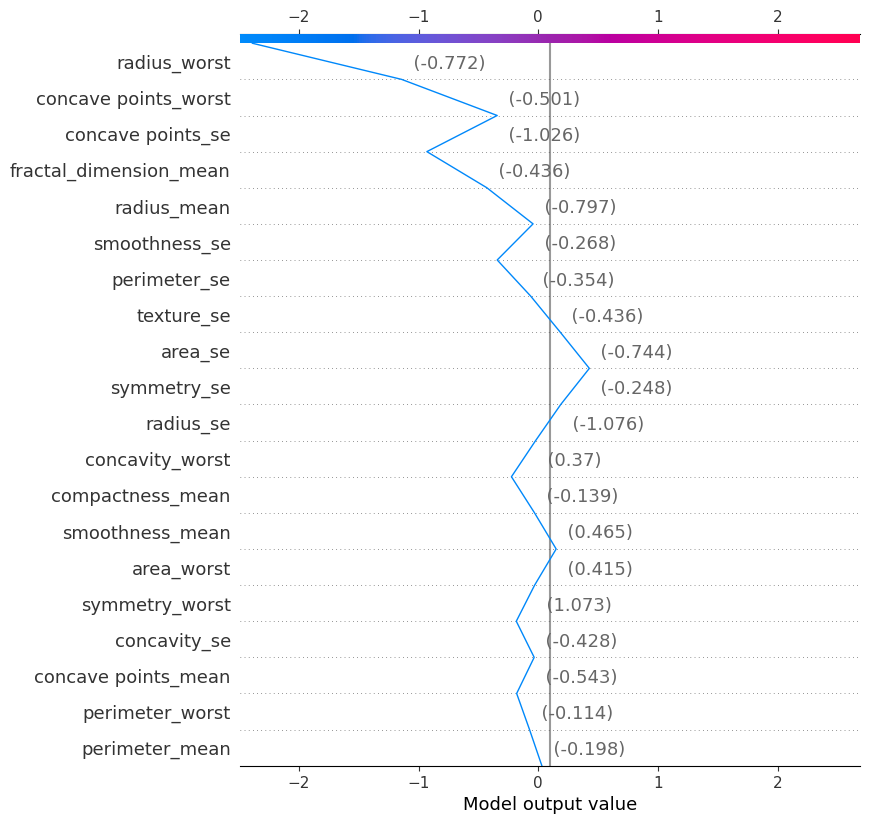

In [37]:
# Decision Plot for Index 20
shap.decision_plot(explainer.expected_value, shap_values[20].values, X_test_df.iloc[20])

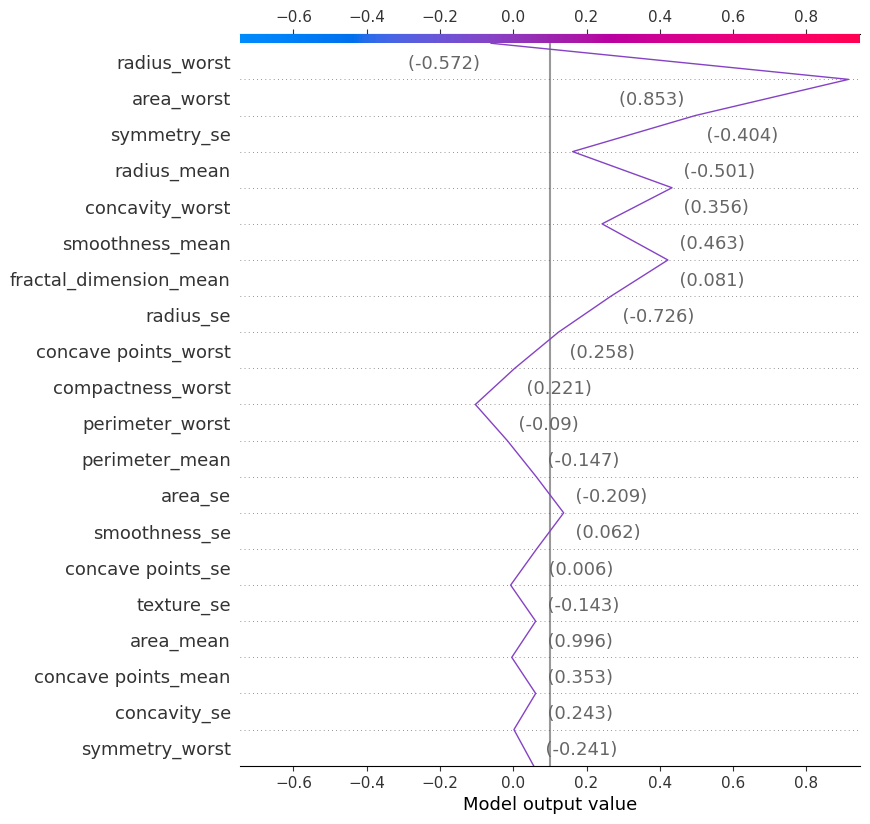

In [38]:
# Decision Plot for Index 77
shap.decision_plot(explainer.expected_value, shap_values[77].values, X_test_df.iloc[77])

## SHAP on a correctly predicted Index: 80

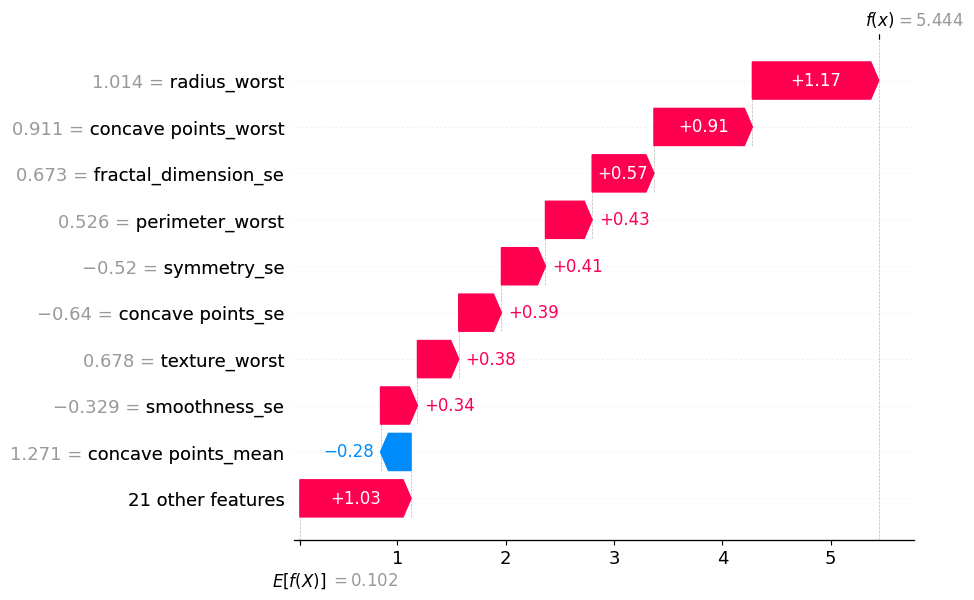

In [39]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test_df)

shap.plots.waterfall(shap_values[80])

In [40]:
shap_index = 80

shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[shap_index].values,
    X_test_df.iloc[shap_index]
)

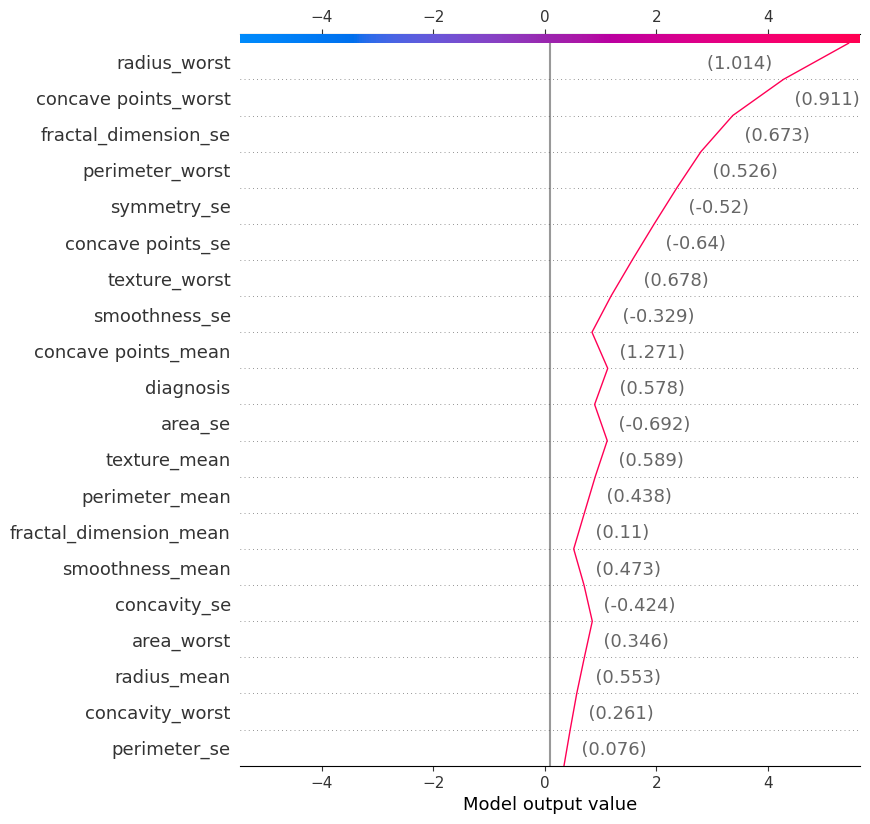

In [41]:
shap.decision_plot(explainer.expected_value, shap_values[80].values, X_test_df.iloc[80])

In [42]:
# Start D-Tale in browser
d = dtale.show(data)
d.open_browser()

#Force plot
shap.initjs()
shap.plots.force(shap_values[0:500])

# SHAP Explanation for Misclassified Indices (112, 20, 77)
### 1. Index 112
#### SHAP force plot and waterfall plot indicate that features such as radius_worst, radius_mean, and concave points_se had a significant impact to predict false positive. Among these features radius_worst has the most influence in the prediction.
#### The decision plot suggests that the model leaned toward a malignant prediction, but some features influenced the prediction toward benign.
### 2. Index 20
#### The force plot shows a high contribution from radius_worst, concave points_worst, and fractal_dimension_mean in predicting falsely     negative.
#### The model struggled to classify this instance due to conflicting feature contributions.
#### The decision plot shows that feature values deviated significantly from typical malignant cases.
### 3. Index 77
#### The waterfall plot highlights that radius_worst, radius_mean, smoothness_mean, and some other features pushed the model to predict falsely negative. However, radius_worst had a huge impact in it
#### The model likely assigned the wrong classification because of feature values close to the decision boundary.
#### The force plot shows opposing contributions, making this instance difficult to classify correctly.
# Model Performance Insights
### Logistic regression performed well overall, achieving 97.37% accuracy.
### SHAP analysis reveals feature importance, explaining why some instances were misclassified.
### radius_worst played an important role in models decision making.
### Misclassifications often occur near decision boundaries, where feature values contribute in conflicting ways.
### In conclusion, the model performed well with only 3 misclassifications out of 114 samples.

## Further development of the model did not improve model's predictibility. So, SHAP is only used to explain few indices from the base logistic regression model. However, effort for improving the model is shown below

## Improving the model

### 1. Hyperparameter Tuning (Adjusting Regularization)

In [43]:
from sklearn.model_selection import GridSearchCV

# Set up parameter grid
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

# Initialize GridSearchCV with Logistic Regression
grid_search = GridSearchCV(LogisticRegression(max_iter=10000), param_grid, cv=5)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Best parameter found by grid search
print(f'Best C value: {grid_search.best_params_}')

# Train with the best C value
best_model = grid_search.best_estimator_

# Evaluate the new model
y_pred_best = best_model.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred_best):.4f}')
print(classification_report(y_test, y_pred_best))

Best C value: {'C': 10}
Accuracy: 0.9737
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        71
           1       0.95      0.98      0.97        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



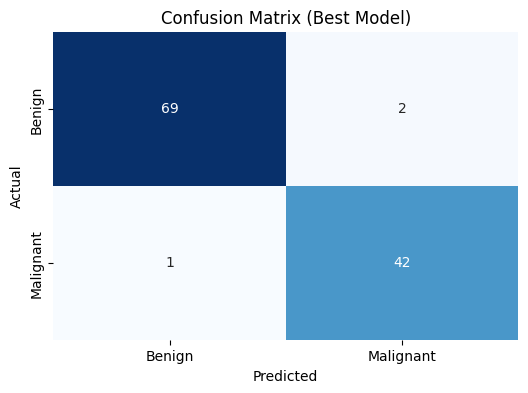

In [44]:
cm_best = confusion_matrix(y_test, y_pred_best)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'], cbar=False)

plt.title('Confusion Matrix (Best Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show the plot
plt.show()

In [45]:
# Identify False Positives and False Negatives
false_positive_indices = np.where((y_pred_best == 1) & (y_test == 0))[0]
false_negative_indices = np.where((y_pred_best == 0) & (y_test == 1))[0]

# Show the number of false positives and false negatives
print(f"False Positives: {len(false_positive_indices)}")
print(f"False Negatives: {len(false_negative_indices)}")

# Print the indices of False Positives and False Negatives
print("False Positive Indices:", false_positive_indices)
print("False Negative Indices:", false_negative_indices)

False Positives: 2
False Negatives: 1
False Positive Indices: [  8 112]
False Negative Indices: [20]


In [46]:
# List of actual feature names
feature_names = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
                 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
                 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se',
                 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst',
                 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst',
                 'symmetry_worst', 'fractal_dimension_worst']

# Get the coefficients from the trained model
coefficients = best_model.coef_[0]

# Create a DataFrame to hold the feature names and their corresponding coefficients
feature_influence = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Sort the features by absolute value of the coefficient
feature_influence['Abs_Coefficient'] = feature_influence['Coefficient'].abs()
feature_influence = feature_influence.sort_values(by='Abs_Coefficient', ascending=False)

# Display the sorted feature influence
print(feature_influence[['Feature', 'Coefficient']])


                    Feature  Coefficient
10                radius_se     3.500717
7       concave points_mean     3.280577
5          compactness_mean    -2.701495
26          concavity_worst     2.579460
28           symmetry_worst     2.577527
21            texture_worst     2.461463
13                  area_se     2.402737
23               area_worst     1.862010
20             radius_worst     1.760707
16             concavity_se    -1.706743
6            concavity_mean     1.585240
19     fractal_dimension_se    -1.488085
18              symmetry_se    -1.242529
17        concave points_se     1.183641
9    fractal_dimension_mean     1.005232
8             symmetry_mean    -0.848441
27     concave points_worst     0.757456
14            smoothness_se     0.743841
11               texture_se    -0.520661
15           compactness_se    -0.247545
25        compactness_worst    -0.191427
2            perimeter_mean    -0.180414
3                 area_mean     0.143463
22          peri

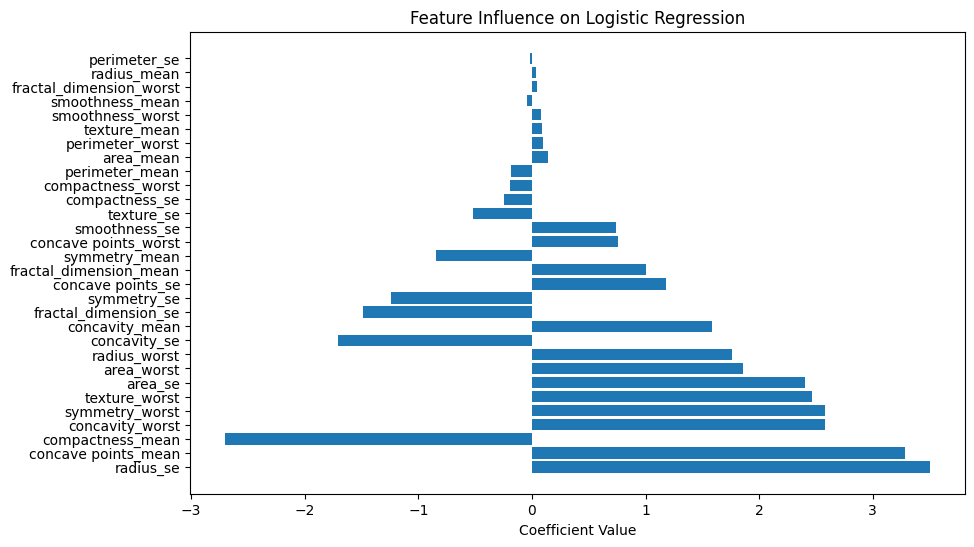

In [47]:
# Plot the feature influence with actual feature names
plt.figure(figsize=(10, 6))
plt.barh(feature_influence['Feature'], feature_influence['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Feature Influence on Logistic Regression')
plt.show()

# Decision Tree Classifier

In [48]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# Initialize the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

In [49]:
# Evaluate the model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f'Accuracy: {accuracy_dt:.4f}')

print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.9474
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



Confusion Matrix:
[[68  3]
 [ 3 40]]


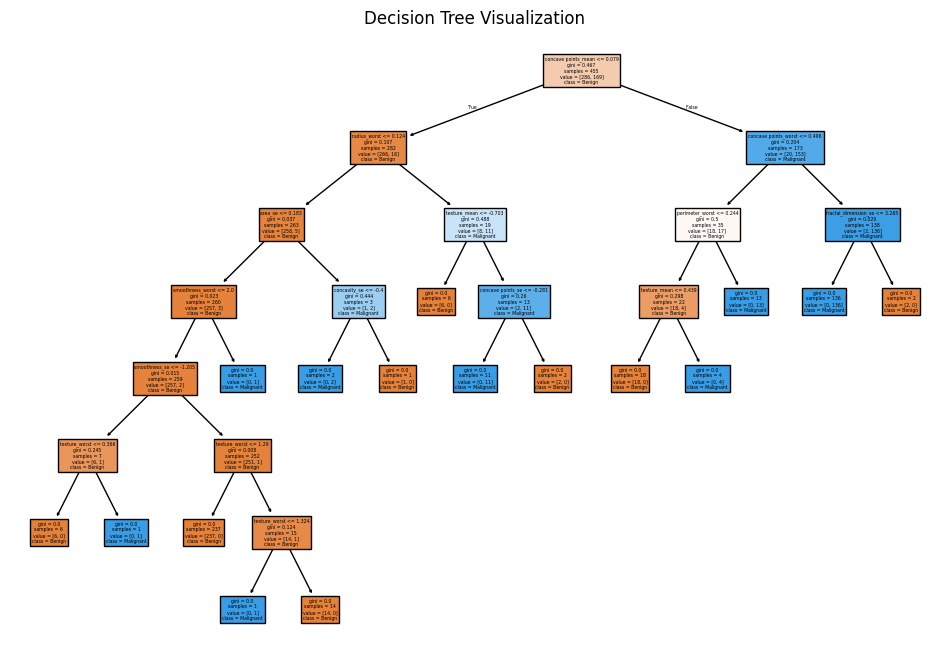

In [50]:
# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

# Plot the Decision Tree
plt.figure(figsize=(12, 8))
plot_tree(dt_model, feature_names=X.columns, class_names=["Benign", "Malignant"], filled=True)
plt.title("Decision Tree Visualization")
plt.show()

In [51]:
# Hyperparameter Tuning using GridSearchCV
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid_search_dt.fit(X_train, y_train)

# Best hyperparameters
print(f'Best Parameters: {grid_search_dt.best_params_}')

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [52]:
# Train and Evaluate the Best Model
best_dt_model = grid_search_dt.best_estimator_
y_pred_best_dt = best_dt_model.predict(X_test)

print(f'Optimized Accuracy: {accuracy_score(y_test, y_pred_best_dt):.4f}')
print(classification_report(y_test, y_pred_best_dt))

Optimized Accuracy: 0.9474
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        71
           1       0.95      0.91      0.93        43

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



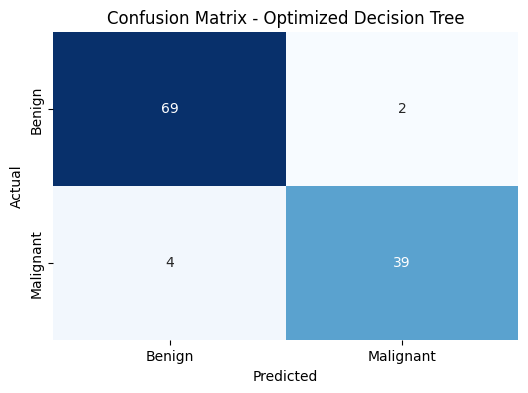

Confusion Matrix:
[[69  2]
 [ 4 39]]


In [53]:
# Make predictions with the best Decision Tree model
y_pred_best_dt = best_dt_model.predict(X_test)

# Compute Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_best_dt)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'], cbar=False)

# Labels and Title
plt.title('Confusion Matrix - Optimized Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show Plot
plt.show()

# Print Confusion Matrix
print("Confusion Matrix:")
print(cm_dt)


# Random Forest Classifier

In [54]:
# Import necessary libraries
from sklearn.ensemble import RandomForestClassifier

In [55]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Random Forest model
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=None)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9649


In [56]:
# Print Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



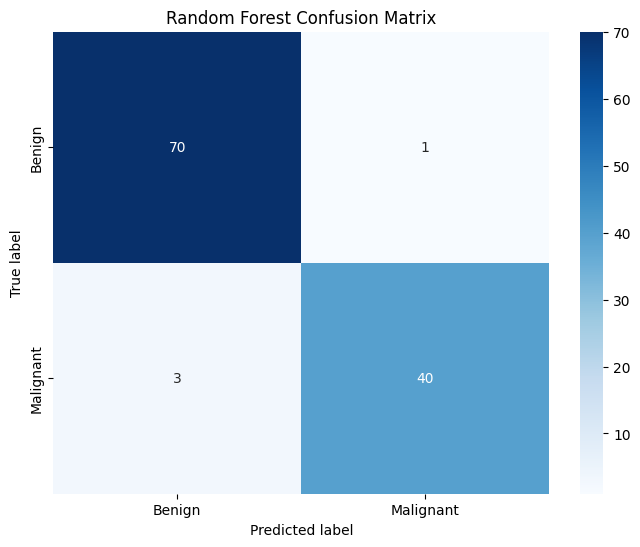

In [57]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualize the Confusion Matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title("Random Forest Confusion Matrix")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

### Precision (0.98 for Malignant, 0.96 for Benign): Model predicts malignant cases well with very few false positives.
### Recall (0.93 for Malignant, 0.99 for Benign): The model is slightly under-detecting malignant cases (some false negatives).
### F1-Score (0.95 for Malignant, 0.97 for Benign): Overall balanced performance.

In [58]:
# Identify False Positives and False Negatives
false_positive_indices = np.where((y_pred == 1) & (y_test == 0))[0]
false_negative_indices = np.where((y_pred == 0) & (y_test == 1))[0]

# Show the number of false positives and false negatives
print(f"False Positives: {len(false_positive_indices)}")
print(f"False Negatives: {len(false_negative_indices)}")

# Print the indices of False Positives and False Negatives
print("False Positive Indices:", false_positive_indices)
print("False Negative Indices:", false_negative_indices)

False Positives: 1
False Negatives: 3
False Positive Indices: [8]
False Negative Indices: [20 77 82]


# Apply hyperprameter tuning

In [59]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees
    'max_depth': [None, 10, 20, 30],  # Tree depth
    'min_samples_split': [2, 5, 10],  # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4]  # Minimum samples per leaf
}

# Initialize Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Perform Grid Search
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Get best parameters
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

# Train the model with best parameters
best_rf_model = RandomForestClassifier(**best_params, random_state=42)
best_rf_model.fit(X_train, y_train)

# Make predictions
y_pred_best = best_rf_model.predict(X_test)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [60]:
# Evaluate performance
accuracy = accuracy_score(y_test, y_pred_best)
print(f"Accuracy after tuning: {accuracy:.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred_best))

Accuracy after tuning: 0.9649
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



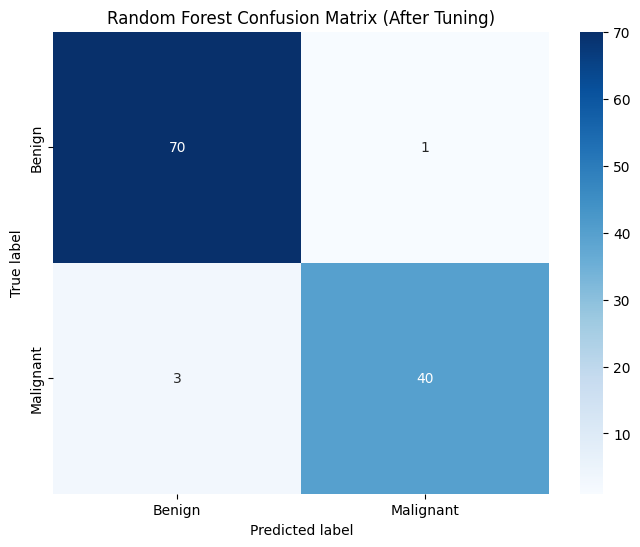

In [61]:
conf_matrix = confusion_matrix(y_test, y_pred_best)

# Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title("Random Forest Confusion Matrix (After Tuning)")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [62]:
# Identify False Positives and False Negatives
false_positive_indices = np.where((y_pred_best == 1) & (y_test == 0))[0]
false_negative_indices = np.where((y_pred_best == 0) & (y_test == 1))[0]

# Show the number of false positives and false negatives
print(f"False Positives: {len(false_positive_indices)}")
print(f"False Negatives: {len(false_negative_indices)}")

# Optionally, print the indices of False Positives and False Negatives
print("False Positive Indices:", false_positive_indices)
print("False Negative Indices:", false_negative_indices)

False Positives: 1
False Negatives: 3
False Positive Indices: [8]
False Negative Indices: [20 77 82]


### No Improvement. Lets do feature importance analysis

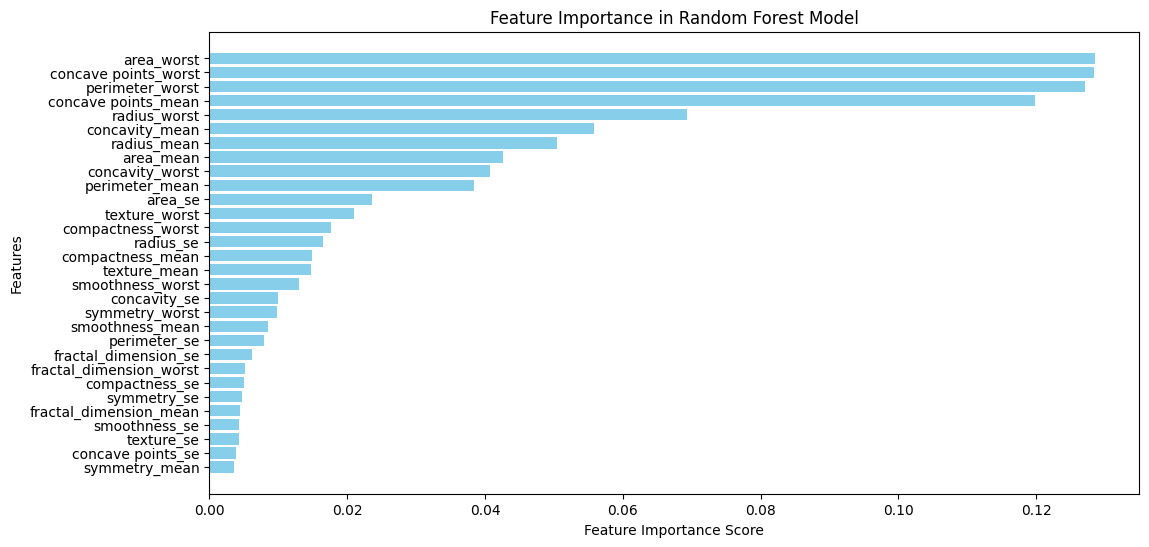

In [63]:
# Get feature importance scores from the trained model
feature_importances = best_rf_model.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Sort features by importance (highest to lowest)
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importance
plt.figure(figsize=(12, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance in Random Forest Model")
plt.gca().invert_yaxis()
plt.show()
